This is a [Google Colaboratory](https://colab.research.google.com/notebooks/welcome.ipynb) notebook file. Python programs are run directly in the browser—a great way to learn and use PyTorch. To follow this tutorial, run the notebook in Google Colab by clicking the button at the top of this page.

1. In Colab, connect to a Python runtime: At the top-right of the menu bar, select *CONNECT*.
2. Run all the notebook code cells: Select *Runtime* > *Run all*.

The goal is to generate an adversarial example. After completion, download the ipynb and submit to canvas.


In [33]:
# --- 1. Setup ---
# Install PyTorch (Colab usually has it preinstalled)
!pip install torch torchvision torchaudio --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.8.0+cu126
CUDA available: True


In [34]:
# --- 2. Tensors ---
# Create some tensors
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
y = torch.ones_like(x)

print("x:\n", x)
print("y:\n", y)
print("x + y =\n", x + y)
print("x * y =\n", x * y)

# Move tensor to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
x = x.to(device)
print(f"x is on {x.device}")

# --- 3. Gradients & Autograd ---
x = torch.randn(3, requires_grad=True)
y = x ** 2
z = y.sum()
z.backward()  # Compute gradients
print("x:", x)
print("x.grad:", x.grad)

x:
 tensor([[1., 2.],
        [3., 4.]])
y:
 tensor([[1., 1.],
        [1., 1.]])
x + y =
 tensor([[2., 3.],
        [4., 5.]])
x * y =
 tensor([[1., 2.],
        [3., 4.]])
x is on cuda:0
x: tensor([ 0.4087,  0.6554, -1.4387], requires_grad=True)
x.grad: tensor([ 0.8174,  1.3109, -2.8774])


In [35]:
# --- 4. Simple Neural Network (MNIST) ---
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

def denormalize(image):
    return image * 0.5 + 0.5

trainset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = SimpleNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 5. Training Loop ---
epochs = 10  # Increase to 5+ for better accuracy
for epoch in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

# --- 6. evaluate the accuracy on test dataset ---
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on test dataset: {100 * correct / total:.2f}%")

Epoch 1, Loss: 0.4038
Epoch 2, Loss: 0.1984
Epoch 3, Loss: 0.1425
Epoch 4, Loss: 0.1169
Epoch 5, Loss: 0.0977
Epoch 6, Loss: 0.0854
Epoch 7, Loss: 0.0761
Epoch 8, Loss: 0.0675
Epoch 9, Loss: 0.0632
Epoch 10, Loss: 0.0566
Accuracy on test dataset: 97.10%


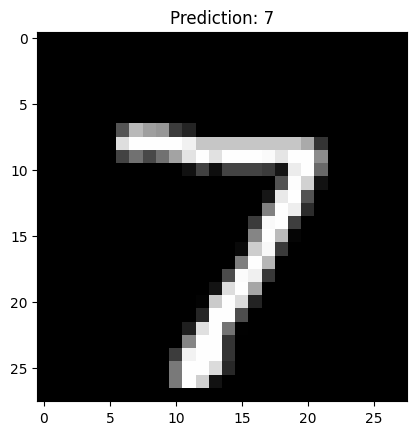

In [36]:
# --- 7. Inference ---
images, labels = next(iter(testloader))
img = images[0].to(device)
true_label = labels[0].to(device)
img.requires_grad = True

logits = model(img.unsqueeze(0))
pred = logits.argmax(dim=1).item()

loss = criterion(logits, true_label.unsqueeze(0))
loss.backward()

img_grad = img.grad
# print(img_grad)

# print(img_grad.data)

plt.imshow(img.cpu().squeeze().detach(), cmap="gray") # Add detach() here
plt.title(f"Prediction: {pred}")
plt.show()

Original Label: 7, Predicted Label: 3


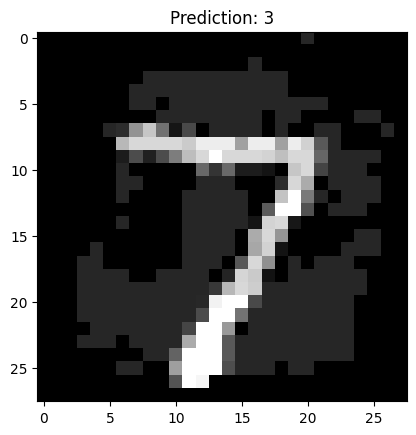

In [37]:
# --- 8. Adversarial Attack ---
org_image = img.detach().clone()
org_label = labels[0].to(device)


perturbed_image = org_image
# TODO: generate the attack image

# def add_noise(image, noise_level):
#     noise = torch.randn_like(image) * noise_level
#     perturbed_image = torch.clamp(image + noise, 0, 1)
#     return perturbed_image

# perturbed_image = add_noise(perturbed_image, 0.7)

# referred https://docs.pytorch.org/tutorials/beginner/fgsm_tutorial.html
# only works for epsilon idx >3
epsilons = [0, .05, .1, .15, .2, .25, .3]

def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image+epsilon*sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0,1)
    return perturbed_image

denormed_img = denormalize(perturbed_image)

perturbed_image = fgsm_attack(denormed_img, epsilons[3], img_grad.data)

with torch.no_grad():
    adv_output = model(perturbed_image.unsqueeze(0))
    adv_pred = adv_output.argmax(dim=1).item()
    print(f"Original Label: {pred}, Predicted Label: {adv_pred}")

assert org_label.item() != adv_pred, "Original and perturbed images should have different labels"

plt.imshow(perturbed_image.detach().cpu().squeeze(), cmap="gray")
plt.title(f"Prediction: {adv_pred}")
plt.show()